# BAA10Y — multivariate conventional-methods comparison

The repo's **financial-markets** reference: a head-to-head of conventional
time-series methods on a daily equity index, all reading the **same leak-safe
covariate panel** (VIX, Treasury yields, the 2s10s spread, fed funds, CPI,
unemployment, oil, gold, the dollar index, NASDAQ), plus an LLM-Process
forecaster that can read those covariates in its prompt.

> Given the same macro/market observations, **which method forecasts the index
> best — and can an LLM-Process, handed those covariates, keep up with gradient
> boosting?**

Unlike the energy/oil reference (univariate price trajectory forecast by
news-grounded / code-executing / adaptive **agents**), this is a clean,
reproducible **numerical-methods bake-off across a covariate panel** — no agents,
no news — scored with CRPS and direction metrics.

**Methods**

| Family | Predictors | Covariates? |
|---|---|---|
| Naive floor | `LastValuePredictor` | — |
| Classical | ETS, Kalman, AutoARIMA | — (univariate) |
| ML regression | Darts LinearRegression, LightGBM | ✅ optional past covariates |
| LLM-Process | `SampledTrajectoryLLMPredictor` | ✅ optional covariate prompt blocks |

**How it's organised.** Specs (`specs/*.yaml`) carry only the **experiment
design** — the window and one single-horizon task per `baa10y_change_{N}b` target.
The **predictors and their hyperparameters live in code** (the predictors cell in
Section 4), so you tune models by editing Python, not YAML.

**Workflow:** iterate on the **2025 backtest** (Section 5) by setting
`EXPERIMENT_CONFIG` in the config cell, then spend the **protected 2026 eval**
(Section 7) on your finalists. `"smoke"` is the fast default.

## What's actually forecastable at daily resolution?

- **Target = change, not the spread level.** We forecast **close-to-close
  cumulative change** over a few horizons, one series per window:
  `baa10y_change_1b` (next session), `baa10y_change_5b` (forward 1 week),
  `baa10y_change_21b` (forward 1 month). Forecasting `baa10y_change_Nb` exactly `N`
  business days ahead resolves to the **forward** cumulative change over the next
  `N` sessions.
- **Per horizon:** `h=1` → direction / next-day **risk management**; `h=5`/`h=21`
  → tactical rebalancing and option tenors as cumulative change.


## ⚠️ Cutoff-aware evaluation — why the windows are what they are

This is the methodological heart of the comparison, and it's easy to get wrong.

- **Numerical methods are cutoff-safe by construction.** Naive, ETS, Kalman,
  AutoARIMA, LinReg and LightGBM only ever see the series up to the forecast
  origin (`ForecastContext` enforces it). They can be backtested on *any*
  historical window — including the 2020 COVID crash.
- **An LLM is not.** Gemini's training cutoff is ~**January 2025**, so it has
  effectively **memorised** outcomes before then. Scoring an LLM-Process on a
  pre-2025 origin measures *recall*, not forecasting — and silently flatters it
  in the head-to-head, which is exactly the comparison this notebook is about.

So the LLM-inclusive comparison lives **after the cutoff**:

| Window | Spec | Role | LLMP? |
|---|---|---|---|
| **2025** | `baa10y_smoke.yaml` / `baa10y_backtest_2025.yaml` | open iteration & comparison | ✅ post-cutoff |
| **2026** | `baa10y_eval_2026.yaml` | **protected** held-out test (budgeted) | ✅ post-cutoff |
| **2020 COVID** | `baa10y_stress_2020.yaml` | volatile-regime stress, **numerical only** | ❌ leaked for LLMs |

This discipline is enforced **in code**: the predictors cell (Section 4) gates the
LLM-Process rows on a `POST_CUTOFF` flag, so selecting `EXPERIMENT_CONFIG =
"stress_2020"` drops them automatically — the numerical methods remain perfectly
valid on that volatile window.

---
## 1. Setup

The heavy lifting lives in helper modules alongside this notebook:

- `data.py`        builds the `DataService` (return targets + the covariate panel).
- `predictors/`    the BAA10Y LLM-Process prompt and sampling recipe.
- `leaderboard.py` turns cached results into the `RESULTS_DF` leaderboard frame.
- `analysis.py` / `plots.py`  direction metrics, styled tables, and figures.

We build **one** data service that registers the three return targets plus the
full covariate panel. Target-only predictors simply ignore the registered
covariates; the covariate variants read them.

**First run on the 2025/2026 windows?** Warm the caches to the present first:
`uv run python scripts/fetch_sp500_market.py --refresh` (Yahoo)
and `uv run python scripts/fetch_fred.py` (traget and macro covariates).

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")


# Resolve the repo root robustly (walk up for the workspace markers) so the
# proxy creds load regardless of the kernel's working directory.
def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "aieng-forecasting").is_dir():
            return cand
    return here


ROOT = _repo_root()
load_dotenv(ROOT / ".env", override=False)  # LLMP rows call the Vector proxy — need PROXY_* set


from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    MultiTargetEvalSpec,
    cached_multi_backtest,
    describe_spec,
    multi_evaluate,
)
from aieng.forecasting.methods import (
    DartsAutoARIMAPredictor,
    DartsExponentialSmoothingPredictor,
    DartsKalmanForecasterPredictor,
    DartsLightGBMPredictor,
    DartsLinearRegressionPredictor,
    LastValuePredictor,
)


In [2]:
# BAA10Y imports

from BAA10Y_forecasting import DEFAULT_COVARIATE_SERIES_IDS, build_baa10y_multivariate_service

from BAA10Y_forecasting.leaderboard import build_leaderboard, build_spread_change_compare_frame

from BAA10Y_forecasting.plots import (
    display_multivariate_backtest_leaderboard,
    plotly_display_multivariate_backtest_leaderboard,
    plot_spread_change_forecast_vs_actual_multi,
    plotly_spread_change_forecast_vs_actual_multi,
    plot_baa10y_spread_change_recent,
    plotly_baa10y_spread_change_recent
)
from BAA10Y_forecasting.predictors import build_baa10y_llmp_sampled_trajectory

In [3]:
#

SPECS_DIR = ROOT / "implementations" / "BAA10Y_forecasting" / "specs"

PREDICTIONS_DIR = ROOT / "data" / "predictions"

In [4]:
# Data environment (not part of any single experiment): how far back to load
# price/covariate history, and whether to re-fetch caches from source.
DATA_HISTORY_START = "2016-01-01"
REFRESH_CACHE = False

#

svc = build_baa10y_multivariate_service(
    windows=(1, 5, 21),
    include_covariates=True,
    covariate_series_ids=DEFAULT_COVARIATE_SERIES_IDS,
    start=DATA_HISTORY_START,
    refresh=REFRESH_CACHE,
)

# The covariate panel available to the with-covariates predictors below (an
# optional FRED feed may be skipped, so filter to what actually registered).
registered = set(svc.series_ids)
COVARIATES = [c for c in DEFAULT_COVARIATE_SERIES_IDS if c in registered]
print("targets:", sorted(s for s in registered if s.startswith("baa10y_change")))
print(f"covariates registered: {len(COVARIATES)} / {len(DEFAULT_COVARIATE_SERIES_IDS)} requested")

targets: ['baa10y_change_1b', 'baa10y_change_21b', 'baa10y_change_5b']
covariates registered: 10 / 11 requested


---
## 2. Configuration

One selector picks the backtest window; everything downstream adapts. Specs are
the source of truth for the **window and tasks** — not the predictors.

In [5]:
# ── Experiment configuration ──────────────────────────────────────────────────
# EXPERIMENT_CONFIG chooses which window drives the backtest (Section 5); all
# downstream cells adapt. The protected 2026 eval (Section 7) is fixed.
#
#   "smoke"          short late-2025 window (~6 weekly origins), post-cutoff.
#                    Fast default; LLM-Process predictors ON.
#   "backtest_2025"  weekly origins across all of 2025 (~50), post-cutoff.
#                    The full comparison; LLMP is slow here — trim the roster.
#   "stress_2020"    the COVID crash (daily origins Feb–Apr 2020). NUMERICAL
#                    ONLY — pre-cutoff is leaked for LLMs, so the predictors cell
#                    drops the LLMP rows for this config.

EXPERIMENT_CONFIG = "smoke"

_BACKTEST_SPEC_FILES = {
    "smoke": "baa10y_smoke.yaml",
    "backtest_2025": "baa10y_backtest_2025.yaml",
    "stress_2020": "baa10y_stress_2020.yaml",
}
_EVAL_SPEC_FILE = "baa10y_eval_2026.yaml"

# 2020 is pre-cutoff → keep the LLM-Process out of the comparison (see Section 0).
POST_CUTOFF = EXPERIMENT_CONFIG in {"smoke", "backtest_2025"}

with (SPECS_DIR / _BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]).open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

print(
    f"Config: {EXPERIMENT_CONFIG!r}  →  {_BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]}  "
    f"(LLMP {'on' if POST_CUTOFF else 'OFF — pre-cutoff'})"
)
print(describe_spec(backtest_spec, data_service=svc))

Config: 'smoke'  →  baa10y_smoke.yaml  (LLMP on)
MultiTargetBacktestSpec (spec_id=baa10y_smoke)
  description: Smoke multivariate demo: weekly origins in late 2025 (post-cutoff), forecasting close-to-close cumulative changes at 1/5/21 business days.
  start:       2025-10-06 00:00:00
  end:         2025-11-14 00:00:00
  stride:      1
  warmup:      250
  tasks:       3

Task: baa10y_change_1b
  description: BAA10Y close-to-close cumulative changes, 1 business day ahead (next-session change / direction).
  horizons:    1
  frequency:   B
  payload:     continuous
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: baa10y_change_1b
    description:    BAA10Y cumulative spread change over 1 business day(s) (next business day)
    source:         FRED (BAA10Y), derived
    units:          basis-points
    frequency:      B

Task: baa10y_change_5b
  description: BAA10Y close-to-close cumulative changes, 5 business days ahead (forward 1-week change).
  horizons:    5
 

---
## 3. Target context — observed returns

The most recent realised next-session returns (the `h=1` target). Blue = index up
over the window, red = down.

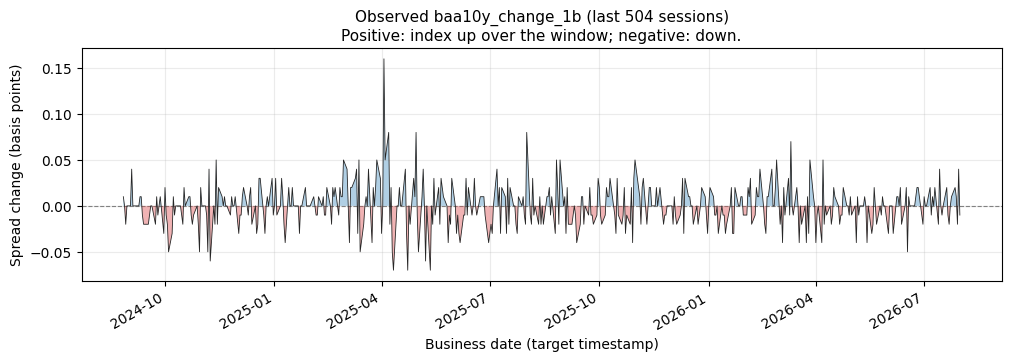

In [6]:
fig, _ = plot_baa10y_spread_change_recent(svc, n_trading_days=504) # Approximately two years
plt.show()

In [7]:
fig = plotly_baa10y_spread_change_recent(svc, n_trading_days=504) # Approximately two years
fig

---
## 4. Predictors — configured in code

This is where you choose the roster. Each predictor implements the same
`Predictor` API against the loaded spec; the conventional methods come straight
from `aieng.forecasting.methods`, and the LLM-Process variants come from the
BAA10Y recipe in `predictors/`. The covariate variants read the registered
`COVARIATES` panel; the target-only variants pass `covariate_series_ids=None`.

| Group | Predictor | Covariates? |
|---|---|---|
| Naive floor | `LastValuePredictor` | — |
| Classical | `DartsExponentialSmoothingPredictor` (ETS), `DartsKalmanForecasterPredictor` | — |
| ML regression | `DartsLinearRegressionPredictor`, `DartsLightGBMPredictor` | target-only **and** + panel |
| LLM-Process | `build_sp500_llmp_sampled_trajectory` | target-only **and** + panel (post-cutoff only) |

`AutoARIMA` is left commented (accurate but slow); add it back for a classical
sweep. The `LLMP (target)` vs `LLMP + cov` pair is the centerpiece — its CRPS gap
answers whether an LLM can use the same exogenous panel the ML methods do.

In [8]:
# Shared hyperparameters for the Darts regression models.
LAGS = 5  # autoregressive lags (and past-covariate lags) for the regression models
NUM_SAMPLES = 100  # empirical-quantile sample count for the probabilistic Darts models
LGBM_KWARGS = {"num_threads": 1, "n_jobs": 1, "verbosity": -1}

# ── Naive floor + classical (univariate) ──────────────────────────────────────
naive = LastValuePredictor()
ets = DartsExponentialSmoothingPredictor(num_samples=NUM_SAMPLES)
kalman = DartsKalmanForecasterPredictor(num_samples=NUM_SAMPLES)
autoarima = DartsAutoARIMAPredictor(num_samples=NUM_SAMPLES)  # accurate but the slowest classical method

# ── ML regression — target-only vs the covariate panel ────────────────────────
linreg = DartsLinearRegressionPredictor(lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES)
linreg_cov = DartsLinearRegressionPredictor(
    lags=LAGS, lags_past_covariates=LAGS, covariate_series_ids=COVARIATES, num_samples=NUM_SAMPLES
)
lightgbm = DartsLightGBMPredictor(
    lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES, lgbm_kwargs=LGBM_KWARGS
)
lightgbm_cov = DartsLightGBMPredictor(
    lags=LAGS,
    lags_past_covariates=LAGS,
    covariate_series_ids=COVARIATES,
    num_samples=NUM_SAMPLES,
    lgbm_kwargs=LGBM_KWARGS,
)

all_predictors = [naive, ets, kalman, autoarima, linreg, linreg_cov, lightgbm, lightgbm_cov]

# Which covariate panel each predictor consumes — drives the leaderboard's
# covariate columns. Predictors absent from this map are treated as target-only.
PREDICTOR_COVARIATES = {
    linreg_cov.predictor_id: COVARIATES,
    lightgbm_cov.predictor_id: COVARIATES,
}
# Short labels for the leaderboard "model" column and the CRPS charts.
PREDICTOR_LABELS = {
    naive.predictor_id: "Naive",
    ets.predictor_id: "ETS",
    kalman.predictor_id: "Kalman",
    autoarima.predictor_id: "AutoARIMA",
    linreg.predictor_id: "LinReg",
    linreg_cov.predictor_id: "LinReg + cov",
    lightgbm.predictor_id: "LightGBM",
    lightgbm_cov.predictor_id: "LightGBM + cov",
}

# ── LLM-Process (sampled trajectories) — target-only vs with-covariates ────────
# Gated on POST_CUTOFF: the 2020 stress window is pre-cutoff and leaked for LLMs,
# so we keep the LLMP rows out of that comparison entirely. The recipe (prompt
# framing, defaults) lives in predictors/llmp_sampled_trajectory.py; tune it
# there, or override model= / n_samples= / history_window= per call here.
if POST_CUTOFF:
    llmp = build_baa10y_llmp_sampled_trajectory(n_samples=8, history_window=48)
    llmp_cov = build_baa10y_llmp_sampled_trajectory(n_samples=8, history_window=48, covariate_series_ids=COVARIATES)
    all_predictors += [llmp, llmp_cov]
    PREDICTOR_COVARIATES[llmp_cov.predictor_id] = COVARIATES
    PREDICTOR_LABELS[llmp.predictor_id] = "LLMP (target)"
    PREDICTOR_LABELS[llmp_cov.predictor_id] = "LLMP + cov"

print(f"{len(all_predictors)} predictors configured (LLMP {'on' if POST_CUTOFF else 'off'}):")
for p in all_predictors:
    print(f"  {p.predictor_id}")

10 predictors configured (LLMP on):
  last_value_naive
  darts_ets
  darts_kalman
  darts_autoarima
  darts_linreg
  darts_linreg_cov
  darts_lightgbm
  darts_lightgbm_cov
  llmp_sampled_trajectories_baa10y_v1_target_h48_n8[gemini-3.1-flash-lite-preview]
  llmp_sampled_trajectories_baa10y_v1_cov_h48_n8[gemini-3.1-flash-lite-preview]


---
## 5. 2025 backtest — the comparison (post-cutoff)

`cached_multi_backtest` runs each predictor across the three single-horizon tasks
and writes every `BacktestResult` to `data/predictions/<spec_id>/` — so a re-run
is free from cache (pass `force_refresh=True` to recompute). The loop prints each
task's mean CRPS as it lands.

In [9]:
results_by_predictor: dict[str, dict[str, object]] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor,
        spec=backtest_spec,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:18s}  mean CRPS = {result.mean_score:.5f}  ({len(result.predictions)} preds)")

RESULTS_DF = build_leaderboard(
    results_by_predictor,
    svc,
    covariates_by_predictor=PREDICTOR_COVARIATES,
    labels_by_predictor=PREDICTOR_LABELS,
)

Running last_value_naive ...
  baa10y_change_1b    mean CRPS = 2.56667  (30 preds)
  baa10y_change_5b    mean CRPS = 5.36667  (30 preds)
  baa10y_change_21b   mean CRPS = 8.96667  (30 preds)
Running darts_ets ...
  baa10y_change_1b    mean CRPS = 1.37963  (30 preds)
  baa10y_change_5b    mean CRPS = 3.98082  (30 preds)
  baa10y_change_21b   mean CRPS = 7.45907  (30 preds)
Running darts_kalman ...
  baa10y_change_1b    mean CRPS = 1.37998  (30 preds)
  baa10y_change_5b    mean CRPS = 2.88129  (30 preds)
  baa10y_change_21b   mean CRPS = 5.33597  (30 preds)
Running darts_autoarima ...
  baa10y_change_1b    mean CRPS = 1.36939  (30 preds)
  baa10y_change_5b    mean CRPS = 3.23254  (30 preds)
  baa10y_change_21b   mean CRPS = 6.99000  (30 preds)
Running darts_linreg ...
  baa10y_change_1b    mean CRPS = 1.34889  (30 preds)
  baa10y_change_5b    mean CRPS = 3.08397  (30 preds)
  baa10y_change_21b   mean CRPS = 6.55291  (30 preds)
Running darts_linreg_cov ...
  baa10y_change_1b    mean CRPS 

In [10]:
#RESULTS_DF.to_csv("BAA10Y_stride=1_5-Aug-2026.csv")

### Leaderboard — mean CRPS by method and horizon

Read it as a story: the spread between methods (and the naive floor's
disadvantage) is widest at `h=1` and compresses by `h=21`. The `dir_*` columns
report next-direction skill (most meaningful at `h=1`).

,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval
0,1,baa10y_change_1b,LightGBM,False,0,—,darts_lightgbm,1.32239,30,30,0,0.500,0.267,0.348,0.500,0.471,30
1,1,baa10y_change_1b,LinReg + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_linreg_cov,1.33730,30,30,0,0.000,0.000,0.000,0.500,0.520,30
2,1,baa10y_change_1b,LinReg,False,0,—,darts_linreg,1.34889,30,30,0,0.000,0.000,0.000,0.467,0.349,30
3,1,baa10y_change_1b,AutoARIMA,False,0,—,darts_autoarima,1.36939,30,30,0,0.400,0.533,0.457,0.367,0.316,30
4,1,baa10y_change_1b,ETS,False,0,—,darts_ets,1.37963,30,30,0,0.333,0.467,0.389,0.267,0.302,30
5,1,baa10y_change_1b,Kalman,False,0,—,darts_kalman,1.37998,30,30,0,0.500,0.533,0.516,0.500,0.422,30
6,1,baa10y_change_1b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,1.41971,30,30,0,0.273,0.200,0.231,0.333,0.338,30
7,1,baa10y_change_1b,LLMP (target),False,0,—,llmp_sampled_trajectories_baa10y_v1_target_h48_n8[gemini-3.1-flash-lite-preview],1.77867,30,30,0,0.500,0.200,0.286,0.500,0.480,30
8,1,baa10y_change_1b,LLMP + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",llmp_sampled_trajectories_baa10y_v1_cov_h48_n8[gemini-3.1-flash-lite-preview],1.87340,30,30,0,0.300,0.200,0.240,0.367,0.393,30
9,1,baa10y_change_1b,Naive,False,0,—,last_value_naive,2.56667,30,30,0,0.533,0.533,0.533,0.533,0.520,30


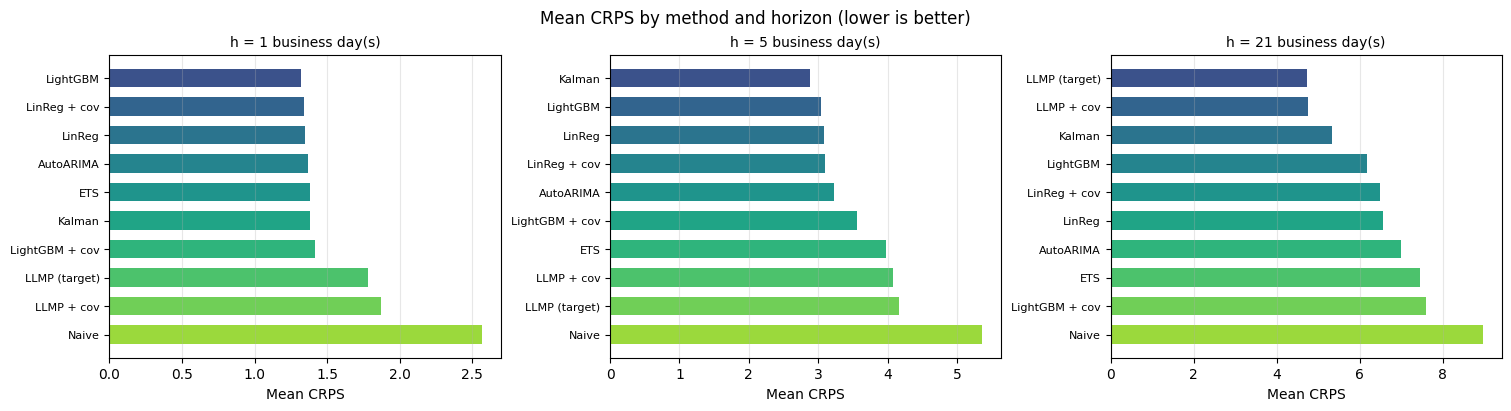

In [11]:
display_multivariate_backtest_leaderboard(RESULTS_DF)

In [12]:
plotly_display_multivariate_backtest_leaderboard(RESULTS_DF)

,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval
0,1,baa10y_change_1b,LightGBM,False,0,—,darts_lightgbm,1.32239,30,30,0,0.500,0.267,0.348,0.500,0.471,30
1,1,baa10y_change_1b,LinReg + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_linreg_cov,1.33730,30,30,0,0.000,0.000,0.000,0.500,0.520,30
2,1,baa10y_change_1b,LinReg,False,0,—,darts_linreg,1.34889,30,30,0,0.000,0.000,0.000,0.467,0.349,30
3,1,baa10y_change_1b,AutoARIMA,False,0,—,darts_autoarima,1.36939,30,30,0,0.400,0.533,0.457,0.367,0.316,30
4,1,baa10y_change_1b,ETS,False,0,—,darts_ets,1.37963,30,30,0,0.333,0.467,0.389,0.267,0.302,30
5,1,baa10y_change_1b,Kalman,False,0,—,darts_kalman,1.37998,30,30,0,0.500,0.533,0.516,0.500,0.422,30
6,1,baa10y_change_1b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,1.41971,30,30,0,0.273,0.200,0.231,0.333,0.338,30
7,1,baa10y_change_1b,LLMP (target),False,0,—,llmp_sampled_trajectories_baa10y_v1_target_h48_n8[gemini-3.1-flash-lite-preview],1.77867,30,30,0,0.500,0.200,0.286,0.500,0.480,30
8,1,baa10y_change_1b,LLMP + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",llmp_sampled_trajectories_baa10y_v1_cov_h48_n8[gemini-3.1-flash-lite-preview],1.87340,30,30,0,0.300,0.200,0.240,0.367,0.393,30
9,1,baa10y_change_1b,Naive,False,0,—,last_value_naive,2.56667,30,30,0,0.533,0.533,0.533,0.533,0.520,30


### Sanity checks
(generated by Claude Sonnet 5)

Cheap consistency checks on `RESULTS_DF` before trusting the leaderboard.

**Check #1 — CRPS should grow with horizon.** For a fixed model, `mean_crps` at
`h=1` should be less than at `h=5`, which should be less than at `h=21`: longer
horizons compound more uncertainty, so a well-behaved scorer should charge more
for them. A model that violates this (flat or decreasing CRPS as horizon grows)
is either genuinely exploiting mean-reversion at longer horizons, or has a bug
(e.g. a horizon-dependent scaling issue, or two horizons mapped to the same cache
entry).

In [13]:
crps_by_model = RESULTS_DF.pivot(index="model", columns="horizon", values="mean_crps").sort_index()

horizons_sorted = sorted(crps_by_model.columns)
is_monotonic = crps_by_model[horizons_sorted].apply(lambda row: row.is_monotonic_increasing, axis=1)

print(f"Check #1 — mean_crps increases with horizon ({horizons_sorted}):")
print(crps_by_model.to_string(float_format=lambda v: f"{v:.4f}"))

violations = crps_by_model.loc[~is_monotonic]
if violations.empty:
    print(f"\nPASS — all {len(crps_by_model)} models have strictly increasing mean_crps across horizons.")
else:
    print(f"\nFAIL — {len(violations)} model(s) do not have strictly increasing mean_crps:")
    print(violations.to_string(float_format=lambda v: f"{v:.4f}"))

Check #1 — mean_crps increases with horizon ([1, 5, 21]):
horizon            1      5      21
model                              
AutoARIMA      1.3694 3.2325 6.9900
ETS            1.3796 3.9808 7.4591
Kalman         1.3800 2.8813 5.3360
LLMP (target)  1.7787 4.1601 4.7214
LLMP + cov     1.8734 4.0710 4.7442
LightGBM       1.3224 3.0413 6.1750
LightGBM + cov 1.4197 3.5515 7.5880
LinReg         1.3489 3.0840 6.5529
LinReg + cov   1.3373 3.0936 6.4784
Naive          2.5667 5.3667 8.9667

PASS — all 10 models have strictly increasing mean_crps across horizons.


**Check #2 — direction accuracy beats a coin flip.** CRPS rewards calibrated
*magnitude*, not sign, so a model can post a great mean_crps while calling the
wrong direction more often than chance. Flag any `(model, horizon)` whose
`dir_accuracy` is significantly below 0.5 (one-sided binomial test on
`dir_n_eval` trials) — that model is directionally *worse than random*, which is
worth understanding even if its CRPS looks fine.

In [14]:
from scipy.stats import binomtest

dir_rows = RESULTS_DF.dropna(subset=["dir_accuracy"])
dir_rows = dir_rows[dir_rows["dir_n_eval"] > 0]


def _worse_than_random(row: pd.Series) -> float:
    n_correct = round(row["dir_accuracy"] * row["dir_n_eval"])
    return binomtest(int(n_correct), int(row["dir_n_eval"]), p=0.5, alternative="less").pvalue


pvals = dir_rows.apply(_worse_than_random, axis=1)
flagged = dir_rows.loc[pvals < 0.1, ["model", "horizon", "dir_accuracy", "dir_n_eval"]].assign(p_value=pvals[pvals < 0.1])

print("Check #2 — direction accuracy vs. 0.5 baseline (one-sided binomial p < 0.1):")
print(
    dir_rows[["model", "horizon", "dir_accuracy", "dir_n_eval"]]
    .sort_values(["horizon", "dir_accuracy"])
    .to_string(index=False, float_format=lambda v: f"{v:.4f}")
)

if flagged.empty:
    print("\nPASS — no model is significantly worse than a coin flip on direction.")
else:
    print(f"\nFLAGGED — {len(flagged)} (model, horizon) row(s) directionally worse than random:")
    print(flagged.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Check #2 — direction accuracy vs. 0.5 baseline (one-sided binomial p < 0.1):
         model  horizon  dir_accuracy  dir_n_eval
           ETS        1        0.2667          30
LightGBM + cov        1        0.3333          30
     AutoARIMA        1        0.3667          30
    LLMP + cov        1        0.3667          30
        LinReg        1        0.4667          30
      LightGBM        1        0.5000          30
  LinReg + cov        1        0.5000          30
        Kalman        1        0.5000          30
 LLMP (target)        1        0.5000          30
         Naive        1        0.5333          30
 LLMP (target)        5        0.3000          30
LightGBM + cov        5        0.3333          30
        LinReg        5        0.3667          30
  LinReg + cov        5        0.3667          30
    LLMP + cov        5        0.5333          30
      LightGBM        5        0.5667          30
        Kalman        5        0.6000          30
     AutoARIMA        5

**Check #3 — every model saw the same origins.** All predictors run against the
same backtest spec, so `n_predictions` (and `skipped_origins`) should match
across models *within* a horizon. A model with fewer predictions than its peers
silently dropped origins (e.g. missing covariate history) and is being scored on
an easier or harder subset of dates than the rest of the leaderboard.

In [15]:
by_horizon = RESULTS_DF.groupby("horizon")[["n_predictions", "n_scores"]].nunique()
uneven_horizons = by_horizon[(by_horizon["n_predictions"] > 1) | (by_horizon["n_scores"] > 1)]

print("Check #3 — n_predictions / n_scores consistent within each horizon:")
print(RESULTS_DF.groupby("horizon")[["n_predictions", "n_scores", "skipped_origins"]].agg(["min", "max"]).to_string())

if uneven_horizons.empty and (RESULTS_DF["skipped_origins"] == 0).all():
    print("\nPASS — every model has the same n_predictions/n_scores per horizon, no skipped origins.")
else:
    print("\nFLAGGED:")
    if not uneven_horizons.empty:
        print(f"  horizons with inconsistent n_predictions/n_scores across models: {list(uneven_horizons.index)}")
    skipped = RESULTS_DF.loc[RESULTS_DF["skipped_origins"] > 0, ["model", "horizon", "skipped_origins"]]
    if not skipped.empty:
        print("  rows with skipped_origins > 0:")
        print(skipped.to_string(index=False))

Check #3 — n_predictions / n_scores consistent within each horizon:
        n_predictions     n_scores     skipped_origins    
                  min max      min max             min max
horizon                                                   
1                  30  30       30  30               0   0
5                  30  30       30  30               0   0
21                 30  30       30  30               0   0

PASS — every model has the same n_predictions/n_scores per horizon, no skipped origins.


**Check #4 — direction-metric plumbing.** `dir_n_eval` (rows the direction join
actually scored) can never exceed `n_predictions`, and every `dir_*` metric must
be either `NaN` (no eval rows) or inside `[0, 1]`. A violation points at a broken
`build_direction_eval_frame` join rather than anything about model quality.

In [16]:
dir_metric_cols = ["dir_precision_up", "dir_recall_up", "dir_f1_up", "dir_accuracy", "dir_roc_auc_prob_up"]

bad_n_eval = RESULTS_DF[RESULTS_DF["dir_n_eval"] > RESULTS_DF["n_predictions"]]
out_of_range = RESULTS_DF[
    RESULTS_DF[dir_metric_cols].apply(lambda col: (col < 0) | (col > 1)).any(axis=1)
]

print("Check #4 — dir_n_eval <= n_predictions, dir_* metrics in [0, 1] or NaN:")
if bad_n_eval.empty and out_of_range.empty:
    print("PASS — no dir_n_eval overruns n_predictions, no dir_* metric out of range.")
else:
    if not bad_n_eval.empty:
        print("FLAGGED — dir_n_eval exceeds n_predictions:")
        print(bad_n_eval[["model", "horizon", "n_predictions", "dir_n_eval"]].to_string(index=False))
    if not out_of_range.empty:
        print("FLAGGED — dir_* metric outside [0, 1]:")
        print(out_of_range[["model", "horizon", *dir_metric_cols]].to_string(index=False))

Check #4 — dir_n_eval <= n_predictions, dir_* metrics in [0, 1] or NaN:
PASS — no dir_n_eval overruns n_predictions, no dir_* metric out of range.


**Check #5 — naive is the CRPS floor.** `LastValuePredictor` sees nothing but the
target series and makes no attempt at forecasting skill, so at every horizon it
should post the *worst* (highest) `mean_crps` among target-only-comparable
models. A method losing to naive means it's adding negative value, not just
"not helping."

In [17]:
naive_label = PREDICTOR_LABELS.get(naive.predictor_id, "Naive")

print("Check #5 — naive holds the highest (worst) mean_crps at every horizon:")
beaten_naive = []
for h, g in RESULTS_DF.groupby("horizon"):
    naive_row = g[g["model"] == naive_label]
    if naive_row.empty:
        continue
    naive_crps = naive_row["mean_crps"].iloc[0]
    worst = g["mean_crps"].max()
    print(f"  h={h:>2}: {naive_label} = {naive_crps:.4f}, worst-in-field = {worst:.4f}")
    if naive_crps < worst:
        beaten = g.loc[g["mean_crps"] > naive_crps, ["model", "mean_crps"]]
        beaten_naive.append((h, beaten))

if not beaten_naive:
    print("\nPASS — naive is the CRPS floor at every horizon.")
else:
    print("\nFLAGGED — models with mean_crps worse than naive:")
    for h, beaten in beaten_naive:
        print(f"  h={h}:")
        print(beaten.to_string(index=False))

Check #5 — naive holds the highest (worst) mean_crps at every horizon:
  h= 1: Naive = 2.5667, worst-in-field = 2.5667
  h= 5: Naive = 5.3667, worst-in-field = 5.3667
  h=21: Naive = 8.9667, worst-in-field = 8.9667

PASS — naive is the CRPS floor at every horizon.


**Check #6 — covariate columns are internally consistent.** `uses_covariates`,
`n_covariates`, and `covariates` are three redundant views of the same
`PREDICTOR_COVARIATES` mapping — they should never disagree (e.g.
`uses_covariates=True` with `n_covariates=0`, or a nonempty `covariates` string
with `n_covariates=0`). A mismatch means a predictor got mislabeled in the
leaderboard-building call, not just a display quirk.

In [18]:
cov_flags = RESULTS_DF[["model", "uses_covariates", "n_covariates", "covariates"]].drop_duplicates()

mismatch = cov_flags[
    (cov_flags["uses_covariates"] != (cov_flags["n_covariates"] > 0))
    | (cov_flags["uses_covariates"] != (cov_flags["covariates"] != "—"))
]

print("Check #6 — uses_covariates / n_covariates / covariates agree:")
print(cov_flags.to_string(index=False))

if mismatch.empty:
    print("\nPASS — all three covariate columns agree for every model.")
else:
    print("\nFLAGGED — inconsistent covariate columns:")
    print(mismatch.to_string(index=False))

Check #6 — uses_covariates / n_covariates / covariates agree:
         model  uses_covariates  n_covariates                                                                                                                                                                                                        covariates
      LightGBM            False             0                                                                                                                                                                                                                 —
  LinReg + cov             True            10 vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b
        LinReg            False             0                                                                                                                             

**Check #7 — no duplicate rows, CRPS is a valid score.** `(model, horizon)`
should be unique (a duplicate usually means the same predictor got added to
`all_predictors` twice, or `build_leaderboard` was called on stale results), and
`mean_crps` — a proper scoring rule — must be finite and non-negative.

In [19]:
import numpy as np

dupes = RESULTS_DF[RESULTS_DF.duplicated(subset=["model", "horizon"], keep=False)]
invalid_crps = RESULTS_DF[(RESULTS_DF["mean_crps"] < 0) | ~np.isfinite(RESULTS_DF["mean_crps"])]

print("Check #7 — unique (model, horizon) rows, mean_crps finite and >= 0:")
if dupes.empty and invalid_crps.empty:
    print(f"PASS — {len(RESULTS_DF)} rows, all (model, horizon) pairs unique, all mean_crps finite and non-negative.")
else:
    if not dupes.empty:
        print("FLAGGED — duplicate (model, horizon) rows:")
        print(dupes[["model", "horizon", "mean_crps"]].to_string(index=False))
    if not invalid_crps.empty:
        print("FLAGGED — invalid mean_crps:")
        print(invalid_crps[["model", "horizon", "mean_crps"]].to_string(index=False))

Check #7 — unique (model, horizon) rows, mean_crps finite and >= 0:
PASS — 30 rows, all (model, horizon) pairs unique, all mean_crps finite and non-negative.


### Reading the LLMP ± covariates rows

When the LLM-Process rows are present (post-cutoff windows), compare them directly:
- **LLMP (target)** — the LLM sees **only** the return history.
- **LLMP + cov** — it additionally sees **labeled covariate-history blocks**
  (VIX, yields, …) in its prompt.

Their CRPS gap answers the headline question: does the same exogenous panel the
ML methods use help an LLM — and does either LLMP variant reach the
gradient-boosting rows? Because these windows are **post-cutoff**, the LLM can't
be reciting memorised outcomes.

---
## 6. Forecast vs realised (next session, h=1)

A few models' median next-session forecast against the realised return (percent)
— the near-zero, low-amplitude forecasts vs the noisy realised series are the
daily-efficiency story made visual. These reuse the cached `h=1` predictions from
Section 5 (no re-running).

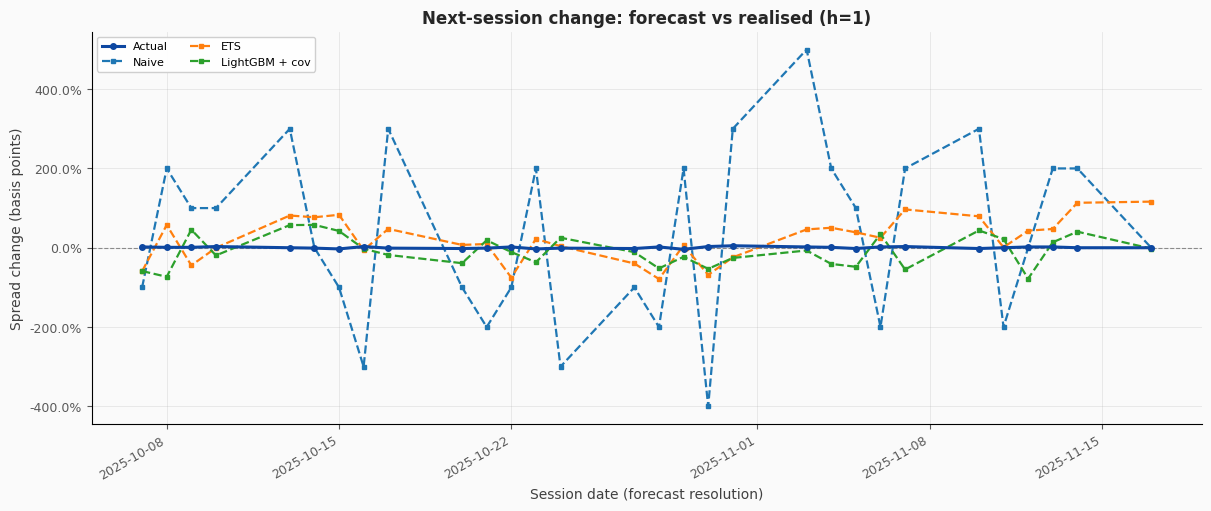

In [20]:
# A few representative models, pulled straight from the cached backtest results.
H1_TASK = "baa10y_change_1b"
demo_ids = [naive.predictor_id, ets.predictor_id, lightgbm_cov.predictor_id]

compare_by_run: dict[str, pd.DataFrame] = {}
for pid in demo_ids:
    result = results_by_predictor.get(pid, {}).get(H1_TASK)
    if result is None:
        continue
    label = PREDICTOR_LABELS.get(pid, pid)
    compare_by_run[label] = build_spread_change_compare_frame(result.predictions, svc, H1_TASK)

fig, _ = plot_spread_change_forecast_vs_actual_multi(compare_by_run, title="Next-session change: forecast vs realised (h=1)")
plt.show()

In [21]:
plotly_spread_change_forecast_vs_actual_multi(compare_by_run, title="Next-session change: forecast vs realised (h=1)")


---
## 7. Protected 2026 eval — the honest scoreboard

`multi_evaluate()` against the held-out 2026 window. This is **scarce**:
`baa10y_eval_2026.yaml` carries `max_runs`, and one `multi_evaluate` call across
all three horizons counts as **one** run. Pass an `EvalTracker` to enforce that
budget across sessions (commented below — it would block re-runs once exhausted,
so we leave it off here and just show `run_number`).

Spend it on the models you committed to from the 2025 backtest — pick a small
**finalists** list in the cell below, not the whole roster. Eval results are
never cached (caching would obscure the budget), so each run recomputes.

> **Runtime:** the finalists default to the cutoff-safe baselines plus
> `LightGBM + cov`. Add the LLMP variants when you're ready to spend the proxy
> tokens on the protected scoreboard (each LLMP eval is ~8 origins × 3 horizons ×
> `n_samples` calls).

In [22]:
# from aieng.forecasting.evaluation import EvalTracker
# tracker = EvalTracker(ROOT / "data" / "baa10y_eval_runs.yaml")  # enforces max_runs across sessions

with (SPECS_DIR / _EVAL_SPEC_FILE).open() as f:
    eval_spec = MultiTargetEvalSpec.model_validate(yaml.safe_load(f))

# Finalists only — the held-out window is scarce. Pick the handful you committed
# to from the 2025 backtest (e.g. add `llmp`, `llmp_cov` here when ready to spend
# the proxy tokens — they exist only when POST_CUTOFF).
eval_finalists = [naive, lightgbm_cov]

eval_results: dict[str, dict[str, object]] = {}
for predictor in eval_finalists:
    print(f"Evaluating {predictor.predictor_id} ...", flush=True)
    eval_results[predictor.predictor_id] = multi_evaluate(
        predictor=predictor,
        spec=eval_spec,
        data_service=svc,
        tracker=None,  # set to `tracker` above to enforce the max_runs budget
    )
    for task_id, result in eval_results[predictor.predictor_id].items():
        print(f"  {task_id:18s}  mean CRPS = {result.mean_score:.5f}  (run #{result.run_number})")

EVAL_DF = build_leaderboard(
    eval_results,
    svc,
    covariates_by_predictor=PREDICTOR_COVARIATES,
    labels_by_predictor=PREDICTOR_LABELS,
)

Evaluating last_value_naive ...
  baa10y_change_1b    mean CRPS = 0.03000  (run #1)
  baa10y_change_5b    mean CRPS = 0.06500  (run #1)
  baa10y_change_21b   mean CRPS = 0.16500  (run #1)
Evaluating darts_lightgbm_cov ...


KeyboardInterrupt: 

,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,run_number
0,1,baa10y_change_1b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.01920,8,8,0,0.500,0.250,0.333,0.500,0.375,8,1
1,1,baa10y_change_1b,Naive,False,0,—,last_value_naive,0.03000,8,8,0,1.000,0.500,0.667,0.750,0.562,8,1
2,5,baa10y_change_5b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.03702,8,8,0,0.667,0.333,0.444,0.375,0.333,8,1
3,5,baa10y_change_5b,Naive,False,0,—,last_value_naive,0.06500,8,8,0,0.667,0.667,0.667,0.500,0.333,8,1
4,21,baa10y_change_21b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.07922,8,8,0,0.000,0.000,0.000,0.500,0.375,8,1
5,21,baa10y_change_21b,Naive,False,0,—,last_value_naive,0.16500,8,8,0,0.333,0.500,0.400,0.250,0.250,8,1


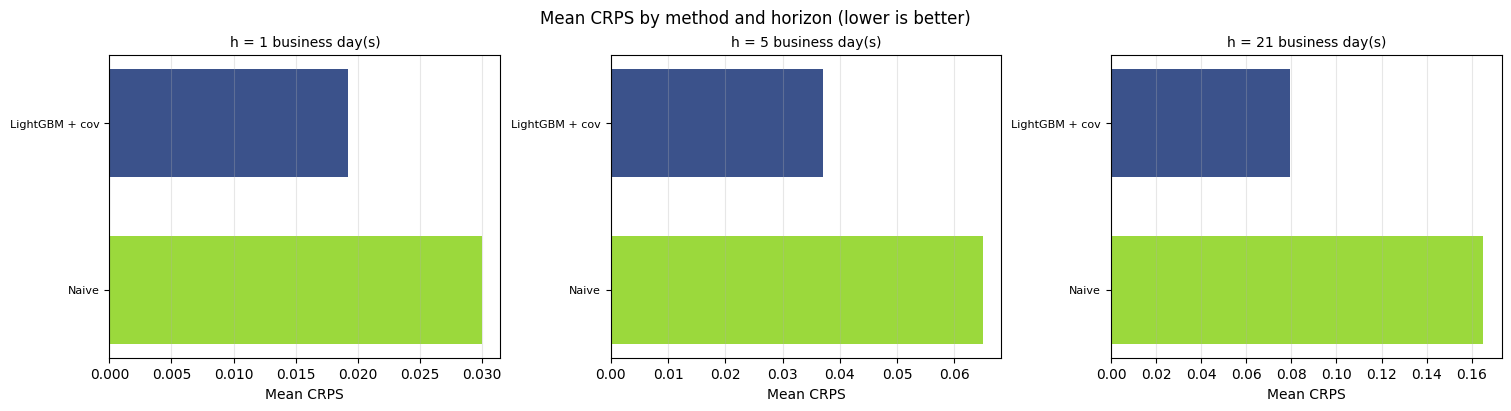

In [ ]:
display_multivariate_backtest_leaderboard(EVAL_DF)

In [ ]:
plotly_display_multivariate_backtest_leaderboard(EVAL_DF)

,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,run_number
0,1,baa10y_change_1b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.01920,8,8,0,0.500,0.250,0.333,0.500,0.375,8,1
1,1,baa10y_change_1b,Naive,False,0,—,last_value_naive,0.03000,8,8,0,1.000,0.500,0.667,0.750,0.562,8,1
2,5,baa10y_change_5b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.03702,8,8,0,0.667,0.333,0.444,0.375,0.333,8,1
3,5,baa10y_change_5b,Naive,False,0,—,last_value_naive,0.06500,8,8,0,0.667,0.667,0.667,0.500,0.333,8,1
4,21,baa10y_change_21b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.07922,8,8,0,0.000,0.000,0.000,0.500,0.375,8,1
5,21,baa10y_change_21b,Naive,False,0,—,last_value_naive,0.16500,8,8,0,0.333,0.500,0.400,0.250,0.250,8,1


---
## Where to go next

- **Scale up the backtest.** Set `EXPERIMENT_CONFIG = "backtest_2025"` (weekly
  origins across all of 2025, full panel) and re-run from Section 2. The LLMP rows
  are slow over ~50 origins — trim `all_predictors` or widen the spec's `stride`.
- **Study the COVID regime (numerical only).** Set
  `EXPERIMENT_CONFIG = "stress_2020"`: a volatile window where a covariate edge is
  most visible. The predictors cell drops the LLMP rows automatically (2020 is
  pre-cutoff, so an LLM would be reciting, not forecasting).
- **Add a method.** Instantiate any `Predictor` (e.g. another Darts model — mirror
  `aieng/forecasting/methods/numerical/darts_classical.py`) in the predictors
  cell and append it to `all_predictors` with a `PREDICTOR_LABELS` entry. No
  registry or dispatch to edit.
- **Tune the LLM-Process.** Edit `predictors/llmp_sampled_trajectory.py` (prompt
  framing, history window) or pass a different `model=` / `n_samples=` in the
  predictors cell. How do the results move?
- **Try an agentic forecaster** with the same cutoff caveats as the LLMP. Do
  agents add lift over LLMPs or the conventional methods?
- **Spend the eval honestly.** Wire the `EvalTracker` in Section 7 so `max_runs`
  is enforced, and only evaluate models you've committed to.